### Bài tập 1: Bias-Variance Trade-off

Yêu cầu 1: Quan sát Overfitting và Underfitting

In [84]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
np.random.seed(42)
n = 30
X = np.sort(np.random.rand(n,1), axis=0)
y  =np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
degree = 3
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


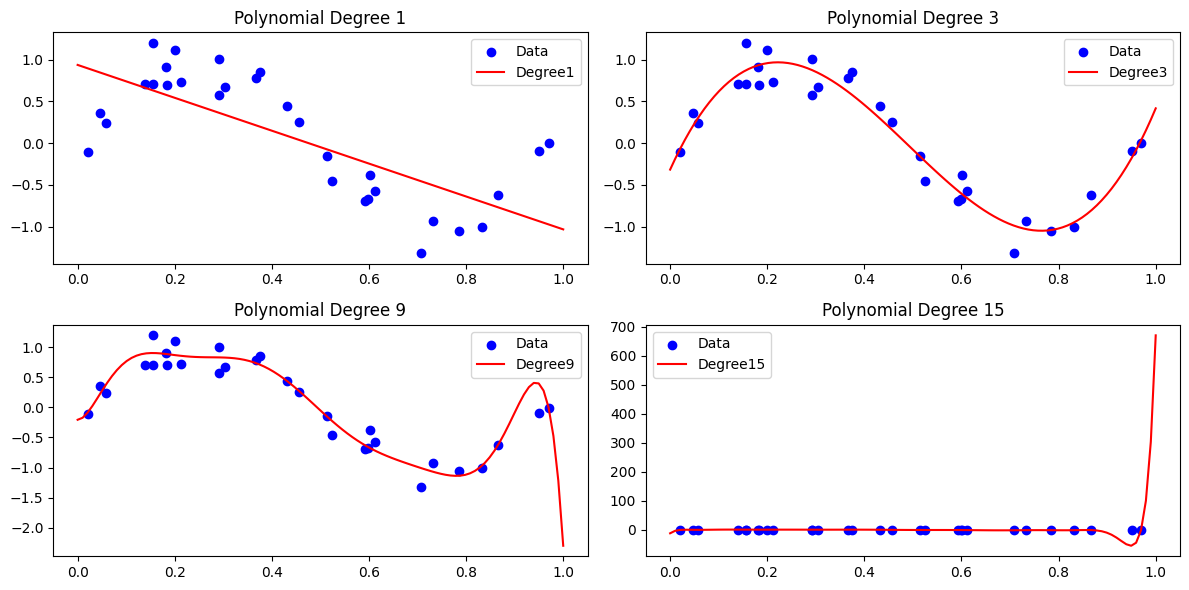

In [8]:
degrees = [1, 3, 9, 15]
plt.figure(figsize=(12, 6))
for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.subplot(2, 2, i+1)
    plt.scatter(X, y, color='blue', label='Data')
    plt.plot(X_plot, y_plot, color='red', label=f'Degree{degree}')
    plt.title(f'Polynomial Degree {degree}')
    plt.legend()
plt.tight_layout()

Yêu cầu 2: Vẽ đường cong Train Error - Test Error

In [ ]:
np.random.seed(42)
n = 30
X = np.sort(np.random.rand(n,1), axis=0)
y  =np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
train_mse = []
test_mse = []
degrees = range(1,16)
for i in degrees:
    poly = PolynomialFeatures(degree=i)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    

### II. Regularization

#### Bài tập 2: Hồi quy Ridge

In [69]:
df = pd.read_csv('abalone.csv')
df = df.dropna()
df = pd.get_dummies(df, columns=["Sex"], dtype=float)

In [70]:
X = df.drop("Rings", axis=1).values.astype(float)
y = df["Rings"].values.astype(float)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [97]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, epochs=1000, batch_size=32, shuffle=True, lambda_=0.1):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.w = None
        self.b = 0
        self.losses = []

    def predict(self, X):
        return X @ self.w + self.b

    def loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def gradient(self, X, y):
        n = X.shape[0]
        y_pred = self.predict(X)
        error = y_pred - y

        dw = (2/n) * (X.T @ error)
        db = (2/n) * np.sum(error)
        return dw, db

    def batch(self, X, y):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        if self.shuffle:
            np.random.shuffle(indices)

        for start in range(0, n_samples, self.batch_size):
            end = start + self.batch_size
            batch_idx = indices[start:end]
            yield X[batch_idx], y[batch_idx]

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0

        for epoch in range(self.epochs):
            for X_batch, y_batch in self.batch(X, y):
                dw, db = self.gradient(X_batch, y_batch)

                dw = np.clip(dw, -10, 10)
                db = np.clip(db, -10, 10)

                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

            y_pred_all = self.predict(X)
            loss_value = self.loss(y, y_pred_all)
            self.losses.append(loss_value)

    def evaluate(self, X, y):
        y_pred = self.predict(X)

        mae = np.mean(np.abs(y - y_pred))
        mse = np.mean((y - y_pred) ** 2)
        rmse = np.sqrt(mse)

        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)

        return mae, mse, rmse, r2

#### Yêu cầu 2.1: Mở rộng class LinearRegression thành RidgeRegression:

In [ ]:
class RidgeRegression(LinearRegression):
    def __init__(self, learning_rate=0.001, epochs=1000, batch_size=32, shuffle=True, lambda_=0.1):
        super().__init__(learning_rate, epochs, batch_size, shuffle)
        self.lambda_ = lambda_

    def gradient(self, X, y):
        n = X.shape[0]
        y_pred = self.predict(X)
        error = y_pred - y

        dw = (2/n) * (X.T @ error) + 2 * self.lambda_ * self.w
        db = (2/n) * np.sum(error)
        return dw, db

In [76]:
model = RidgeRegression(
    learning_rate=0.001,
    epochs=500,
    batch_size=32,
    lambda_=0.1
)
model.fit(X_train, y_train)

mae, mse, rmse, r2 = model.evaluate(X_test, y_test)

In [78]:
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

print("\nLoss ở Epoch cuối:", model.losses[-1])

MAE  : 1.7375
MSE  : 6.1013
RMSE : 2.4701
R2   : 0.4791

Loss ở Epoch cuối: 5.306120104690331


#### Yêu cầu 2.2: Phân tích hiện tượng co trọng số

In [81]:
lambdas = [0, 0.1, 1, 10, 100, 1000]
weight = []

for lam in lambdas:
    model = RidgeRegression(
        learning_rate=0.001,
        epochs=500,
        batch_size=32,
        lambda_=lam
    )
    model.fit(X_train, y_train)
    weight.append(model.w.copy())

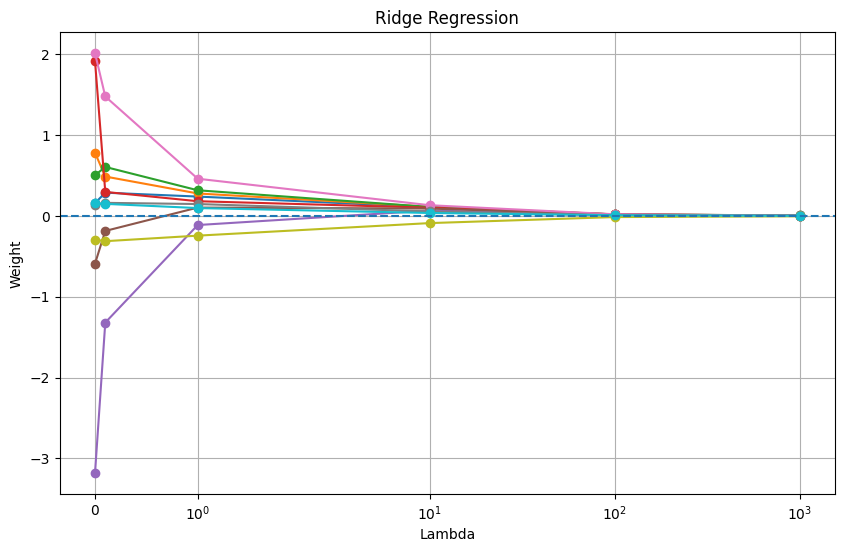

In [85]:
weight = np.array(weight)
plt.figure(figsize=(10,6))

n_features = weight.shape[1]

for j in range(n_features):
    plt.plot(lambdas, weight[:, j], marker='o')

plt.xscale("symlog")

plt.xlabel("Lambda")
plt.ylabel("Weight")
plt.title("Ridge Regression")

plt.axhline(0, linestyle="--")

plt.grid(True)
plt.show()

### Bài tập 3: Hồi quy Lasso

##### Yêu cầu 3.1: Mở rộng class LinearRegression thành LassoRegression:

In [98]:
class LassoRegression(LinearRegression):
    def __init__(self, learning_rate=0.001, epochs=1000, batch_size=32, shuffle=True, lambda_=0.1):
        super().__init__(learning_rate, epochs, batch_size, shuffle)
        self.lambda_ = lambda_

    def gradient(self, X, y):

        n = X.shape[0]

        y_pred = self.predict(X)
        error = y_pred - y

        dw = (2/n) * (X.T @ error) + self.lambda_ * np.sign(self.w)
        db = (2/n) * np.sum(error)

        return dw, db

    def loss(self, y_true, y_pred):
        mse_loss = np.mean((y_true - y_pred) ** 2)
        l1_penalty = self.lambda_ * np.sum(np.abs(self.w))
        return mse_loss + l1_penalty


In [99]:
model = LassoRegression(
    learning_rate=0.001,
    epochs=1000,
    batch_size=32,
    shuffle=True,
    lambda_=0.1
)

model.fit(X_train, y_train)

mae, mse, rmse, r2 = model.evaluate(X_test, y_test)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

print("\nLoss ở Epoch cuối:", model.losses[-1])

MAE  : 1.6841
MSE  : 5.7245
RMSE : 2.3926
R2   : 0.5112

Loss ở Epoch cuối: 5.635070830458507


In [100]:
lambdas = [0, 0.1, 1, 10, 100, 1000]
weight = []

for lam in lambdas:
    model = LassoRegression(
        learning_rate=0.001,
        epochs=1000,
        batch_size=32,
        lambda_=lam
    )
    model.fit(X_train, y_train)
    weight.append(model.w.copy())

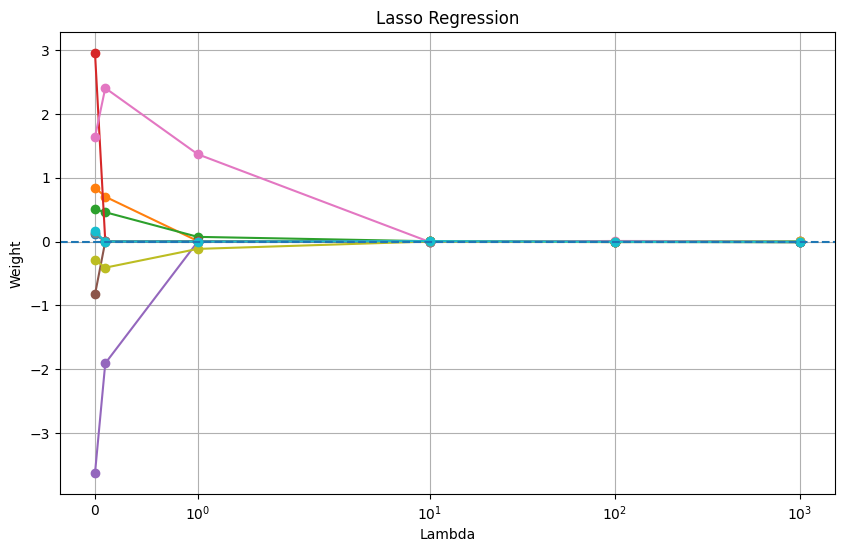

In [101]:
weight = np.array(weight)
plt.figure(figsize=(10,6))

n_features = weight.shape[1]

for j in range(n_features):
    plt.plot(lambdas, weight[:, j], marker='o')

plt.xscale("symlog")

plt.xlabel("Lambda")
plt.ylabel("Weight")
plt.title("Lasso Regression")

plt.axhline(0, linestyle="--")

plt.grid(True)
plt.show()